# What are the most demanded skills forthe most popular Data Roles in the US?
## Methodology
1: Clean up skill column
2:Calculate Skill Count based on "job_title_short"
3: Calculate final percentage 
4: plot skill findings 




In [1]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as  sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


In [2]:
df_US=df[(df['job_country']== 'United States')]

In [3]:
df_skills=df_US.explode('job_skills')

In [4]:
df_skills[['job_title','job_skills']]

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,None
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
...,...,...
785692,Data Scientist- Hybrid Work Location,r
785703,Data Analyst - CRYPTOGRAPHY - Full-time,None
785705,Expert Business Data Analyst - Now Hiring,sql
785705,Expert Business Data Analyst - Now Hiring,python


In [5]:
df_skill_count= df_skills.groupby(['job_skills','job_title_short']).size()
df_skill_count=df_skill_count.reset_index(name='skill_count')
df_skill_count.sort_values(by='skill_count',ascending= False, inplace= True )
df_skill_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [6]:
job_titles = df_skill_count['job_title_short'].unique().tolist()

job_titles = job_titles[:3]

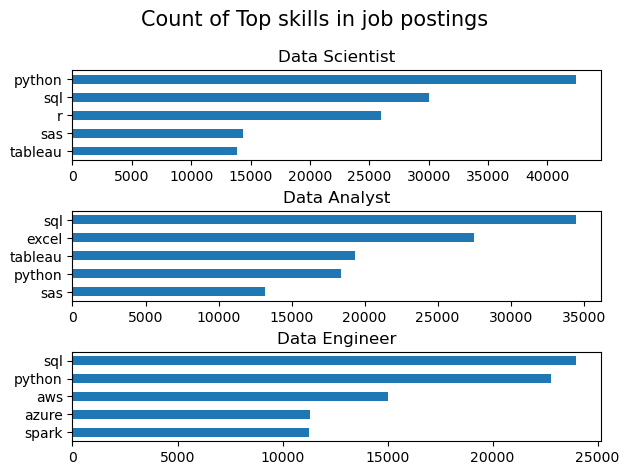

In [7]:
fig, ax= plt.subplots(len(job_titles),1)
for i, job_title in enumerate (job_titles):

    df_plot = df_skill_count[df_skill_count['job_title_short']== job_title].head(5)
    df_plot.plot(kind='barh', x = 'job_skills', y ='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Count of Top skills in job postings', fontsize = 15)
fig.tight_layout(h_pad=0.5)
plt.show()

In [8]:
df_job_title_count=df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [9]:
df_skills_perc = pd.merge(df_skill_count,df_job_title_count, how= 'left',on='job_title_short')

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total
0,python,Data Scientist,42379,58830
1,sql,Data Analyst,34452,67816
2,sql,Data Scientist,30034,58830
3,excel,Data Analyst,27519,67816
4,r,Data Scientist,26022,58830
...,...,...,...,...
1865,vue.js,Business Analyst,1,7382
1866,arch,Business Analyst,1,7382
1867,asana,Machine Learning Engineer,1,921
1868,no-sql,Machine Learning Engineer,1,921


In [10]:
df_skills_perc['skill_percent']= 100 * df_skills_perc['skill_count']/df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


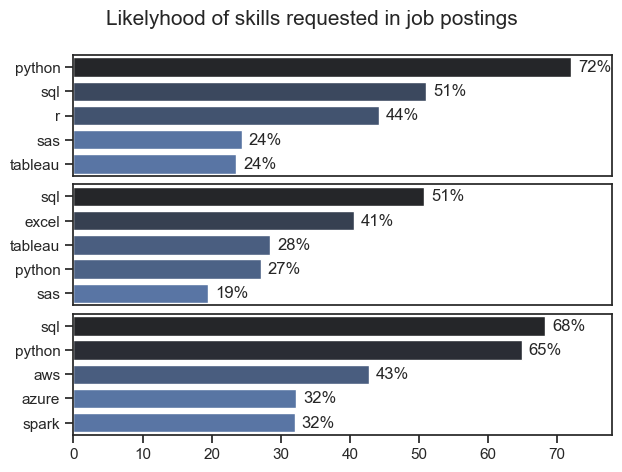

In [22]:
fig, ax= plt.subplots(len(job_titles),1)
for i, job_title in enumerate (job_titles):

    df_plot = df_skills_perc[df_skills_perc['job_title_short']== job_title].head(5)
    #df_plot.plot(kind='barh', x = 'job_skills', y ='skill_percent', ax=ax[i], title=job_title)
    sns.set_theme(style='ticks')
    sns.barplot(data=df_plot,x='skill_percent',y='job_skills',ax=ax[i],hue= 'skill_percent', palette='dark:b_r')
    #ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,78)

    for n, v in enumerate (df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va= 'center')
    if i != len(job_titles)-1:
        ax[i].set_xticks([])
fig.suptitle('Likelyhood of skills requested in job postings', fontsize = 15)
fig.tight_layout(h_pad=0.5)
plt.show()